# ****Wlecome to my Uber Fare Amount Model Predection 🚖****

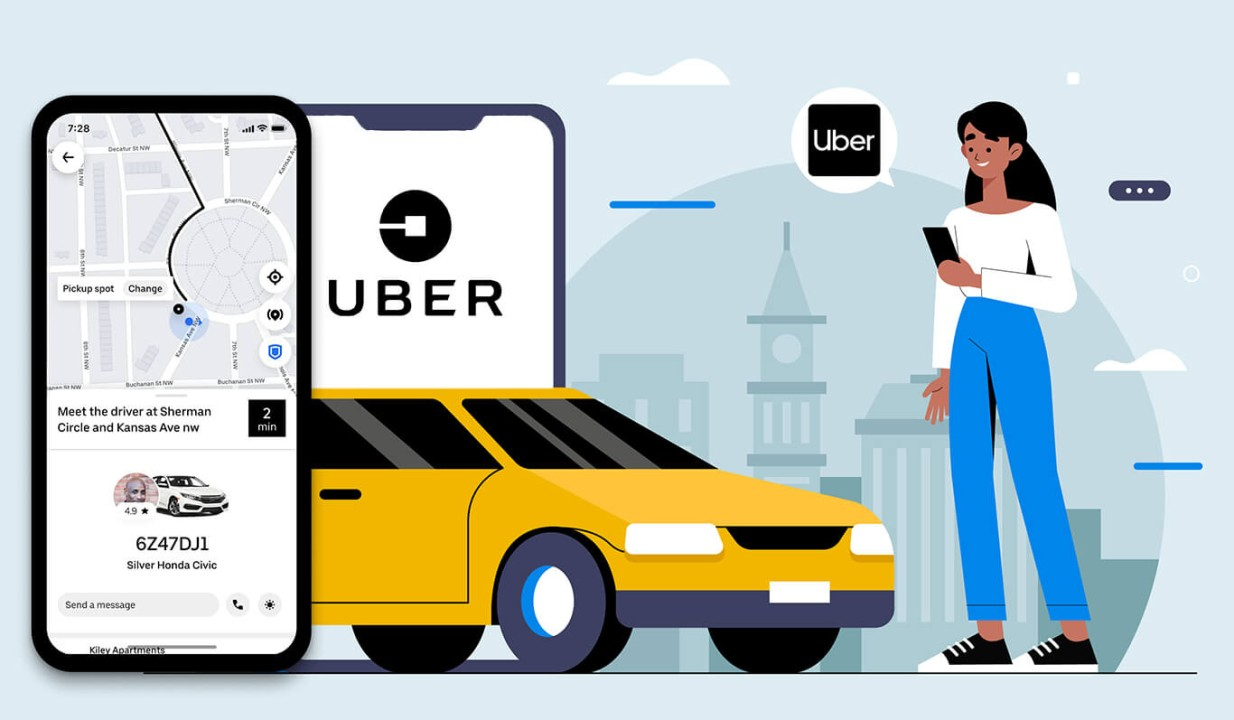

# ***KEY POINTS FOR END-TO-END MODEL📍***:
#### [1-Define the Problem](#DefinetheProblemorResearchQuestion)

#### [2-Data Acquisition:](#DataAcquisition)

#### [3-Data Cleaning and Preprocessing](#DataCleaningandPreprocessing)

#### [4-Exploratory Data Analysis (EDA)](#ExploratoryDataAnalysis(EDA))

#### [5-Feature Engineering & Data Transformation](#FeatureEngineering&DataTransformation)

#### [6-Splitting Data](#SplittingData)

#### [7-Model Selection](#ModelSelection)

#### [8-Model Training](#ModelTraining)

#### [9-Hyperparameter Tuning](#HyperparameterTuning)

#### [10-Model Evaluation](#ModelEvaluation)

#### [11- Final Model and Deployment with Django](#FinalModelandDeploymentwithDjango)


<a id='DefinetheProblemorResearchQuestion'></a>

# 1-Define the Problem:
**Objective:**  Develop a robust model that accurately predicts Uber fare amounts.

**Business Need:** Improve customer transparency and operational planning by providing reliable fare estimates.

**Challenges:** Address the complexities of variable factors (traffic, weather, time, geospatial data) and overcome issues like missing data and outliers.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.feature_selection import RFE
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from scipy.stats import boxcox, yeojohnson
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler, StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from ydata_profiling import ProfileReport
%matplotlib inline
warnings.filterwarnings("ignore")

<a id='DataAcquisition'></a>

#  2-Data Acquisition:

In [2]:
data = pd.read_csv('Upper_Fair_Amount')
data.head(5)

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [3]:
data.shape

(500000, 26)

<a id='DataCleaningandPreprocessing'></a>

# 3-Data Cleaning and Preprocessing

****ProfileReport will help me to know more about data and the problems i shuold solve it****

In [4]:
profile = ProfileReport(data, title='Pandas Profiling Report', explorative=True)

In [1]:
#profile

In [6]:
print(data.isnull().sum())

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64


In [7]:
data.dropna(inplace=True)

In [8]:
data.duplicated().sum()

0

In [9]:
(data['fare_amount']<=0).sum()

35

In [10]:
data=data[data['fare_amount']>0]

In [11]:
(data['passenger_count']<0).sum()

0

In [12]:
(data['distance']<0).sum()

0

In [13]:
# Filter geographic coordinates based on NYC expected ranges (in radians)
# NYC approx (in radians): Longitude between -1.5 and -1.0, Latitude between 0.60 and 0.80
coord_filter = (
    (data['pickup_longitude'] >= -1.5) & (data['pickup_longitude'] <= -1.0) &
    (data['pickup_latitude']  >= 0.60)  & (data['pickup_latitude']  <= 0.80) &
    (data['dropoff_longitude'] >= -1.5) & (data['dropoff_longitude'] <= -1.0) &
    (data['dropoff_latitude']  >= 0.60)  & (data['dropoff_latitude']  <= 0.80)
)
data=data[coord_filter]

In [14]:
# Standardize Categorical Values
categorical_cols = ['Car Condition', 'Weather', 'Traffic Condition']
for col in categorical_cols:
    data[col] = data[col].astype(str).str.strip().str.lower()

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489671 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            489671 non-null  object 
 1   User Name          489671 non-null  object 
 2   Driver Name        489671 non-null  object 
 3   Car Condition      489671 non-null  object 
 4   Weather            489671 non-null  object 
 5   Traffic Condition  489671 non-null  object 
 6   key                489671 non-null  object 
 7   fare_amount        489671 non-null  float64
 8   pickup_datetime    489671 non-null  object 
 9   pickup_longitude   489671 non-null  float64
 10  pickup_latitude    489671 non-null  float64
 11  dropoff_longitude  489671 non-null  float64
 12  dropoff_latitude   489671 non-null  float64
 13  passenger_count    489671 non-null  int64  
 14  hour               489671 non-null  int64  
 15  day                489671 non-null  int64  
 16  month  

In [16]:
# 3. Review Zero Values in Coordinate Columns
coord_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
for col in coord_cols:
    zero_count = (data[col] == 0).sum()
    print(f"Column {col} has {zero_count} zero values.")

Column pickup_longitude has 0 zero values.
Column pickup_latitude has 0 zero values.
Column dropoff_longitude has 0 zero values.
Column dropoff_latitude has 0 zero values.


In [17]:
print("Final data shape:", data.shape)

Final data shape: (489671, 26)


In [18]:
data = data.drop(['User ID', 'User Name', 'Driver Name', 'pickup_datetime','key'], axis=1)

<a id='ExploratoryDataAnalysis(EDA)'></a>

# 4-Exploratory Data Analysis (EDA)📊

# 1-Descriptive statistics📈

In [19]:
data.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000,489671.000000
mean,11.343463,-1.291111,0.711238,-1.291094,0.711244,1.683937,13.512577,15.679185,6.269567,3.041824,2011.736298,41.955931,35.767693,19.662122,19.007924,11.273137,3.359526,0.303951
std,9.845535,0.000840,0.000595,0.000798,0.000671,1.307582,6.507676,8.680823,3.439489,1.948871,1.863180,7.383465,8.139342,7.446008,8.554638,8.657303,4.445354,1.821036
min,0.010000,-1.407026,0.653100,-1.374014,0.602747,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291409,0.710987,-1.291396,0.710970,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.307959,32.119320,17.039478,14.809704,7.074764,1.255553,-0.877996
50%,8.500000,-1.291231,0.711281,-1.291205,0.711289,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.480336,34.670782,19.497262,18.207566,10.327864,2.153716,-0.099554
75%,12.500000,-1.290991,0.711527,-1.290937,0.711543,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.681505,38.054992,22.024819,22.134485,14.169040,3.926717,2.239756
max,500.000000,-1.178595,0.754226,-1.149635,0.778417,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,1315.288529,1368.469312,1315.950977,1350.136675,1342.029311,696.278822,3.141593


In [20]:
data.select_dtypes(include=[np.number]).kurt()

fare_amount            84.479253
pickup_longitude     2910.526568
pickup_latitude       683.160094
dropoff_longitude    3344.396698
dropoff_latitude     2170.198811
passenger_count         2.755748
hour                   -0.765141
day                    -1.158525
month                  -1.199710
weekday                -1.199556
year                   -1.145659
jfk_dist             4536.547527
ewr_dist             3287.080961
lga_dist             4820.569514
sol_dist             2859.471264
nyc_dist             2805.629761
distance             2410.153395
bearing                -1.138570
dtype: float64

In [21]:
data.select_dtypes(include=[np.number]).skew()

fare_amount           4.870349
pickup_longitude     -0.349961
pickup_latitude      -2.535794
dropoff_longitude     9.548561
dropoff_latitude     -7.159572
passenger_count       1.972892
hour                 -0.435104
day                   0.020928
month                 0.109604
weekday              -0.041590
year                  0.067350
jfk_dist             41.913291
ewr_dist             35.023099
lga_dist             46.381443
sol_dist             32.054414
nyc_dist             32.005343
distance             24.756667
bearing              -0.031231
dtype: float64

# 2-Univariate analysis🔎

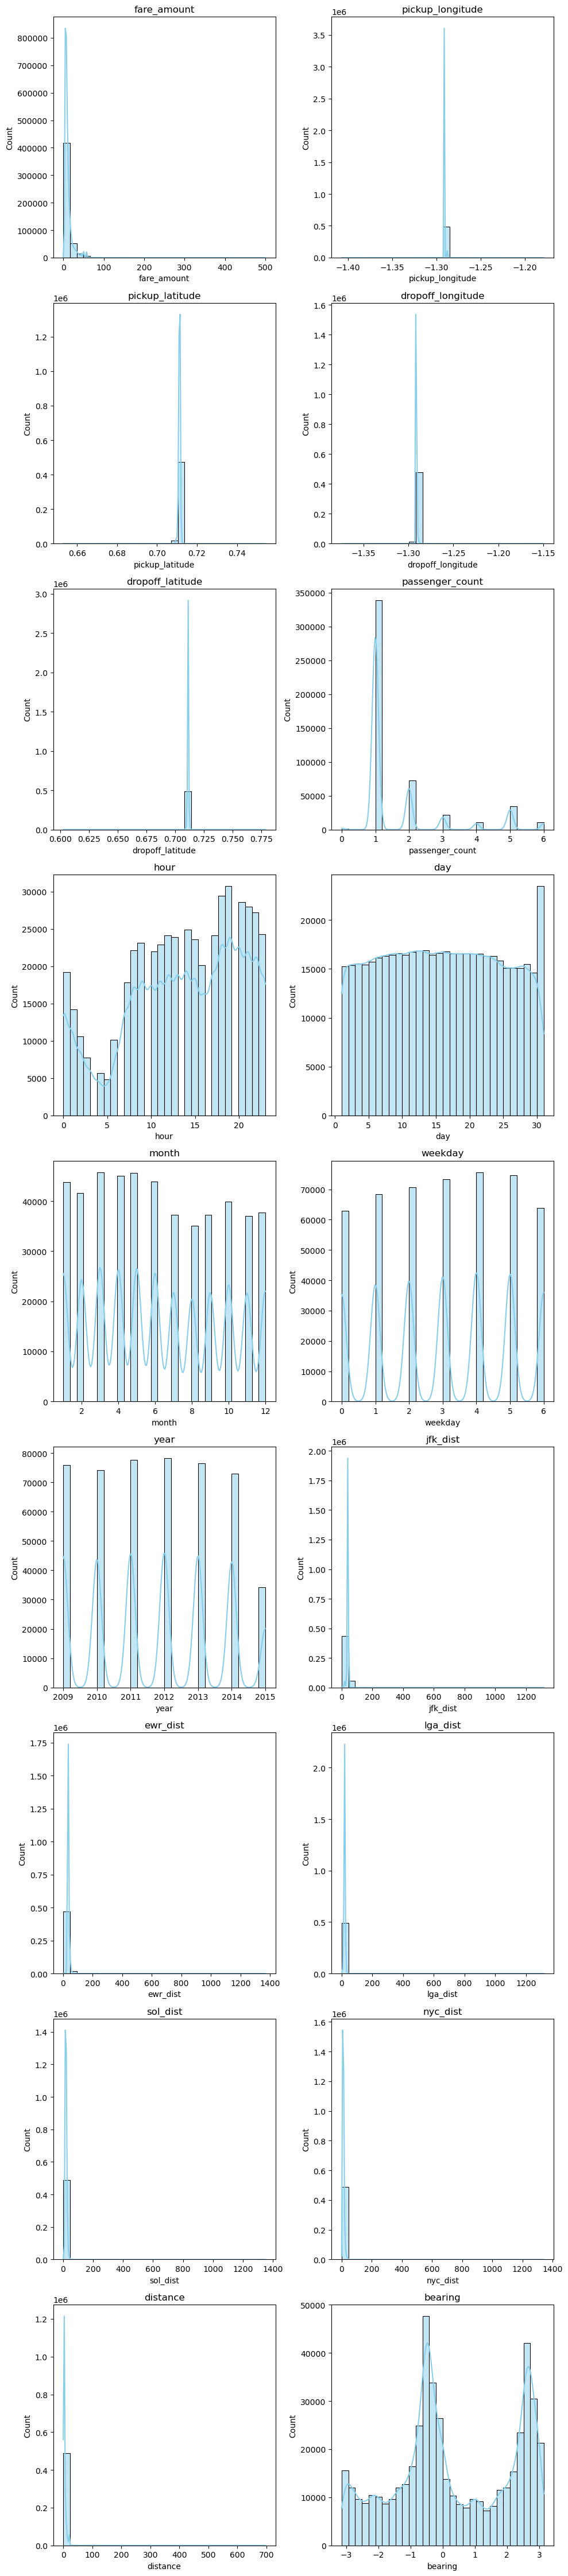

In [22]:
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
n_cols =2 
n_rows = math.ceil(len(numeric_columns) / n_cols)
plt.figure(figsize=(5* n_cols, 5 * n_rows))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[col], kde=True, bins=30, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

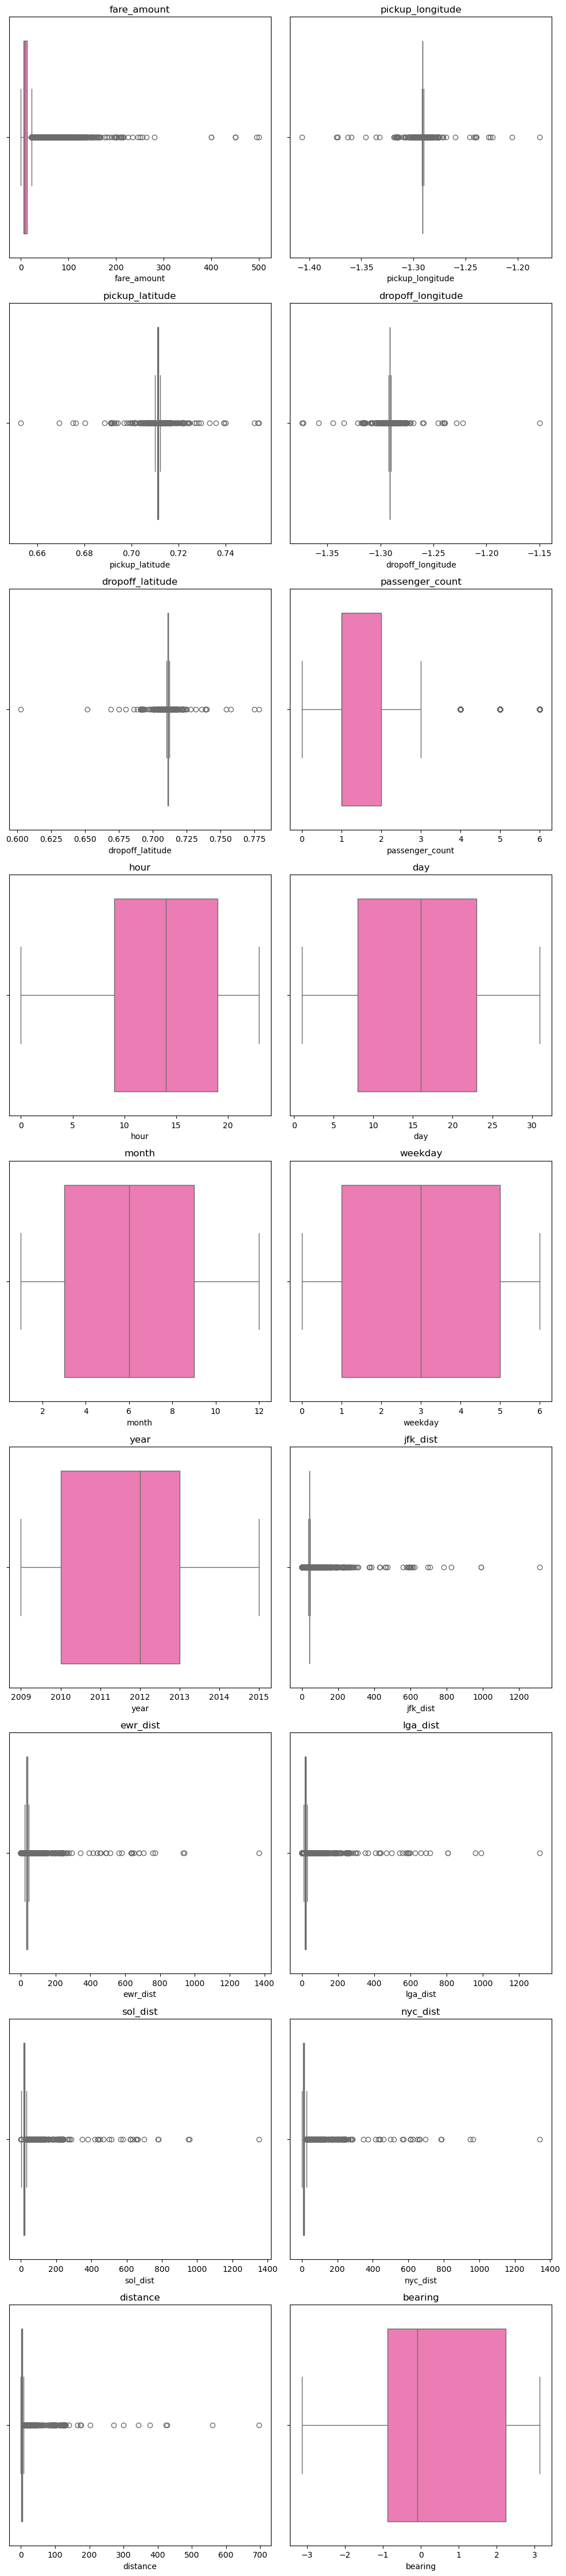

In [23]:
plt.figure(figsize=(5 * n_cols, 5* n_rows))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[col], color='hotpink')
    plt.title(col)
plt.tight_layout()
plt.show()

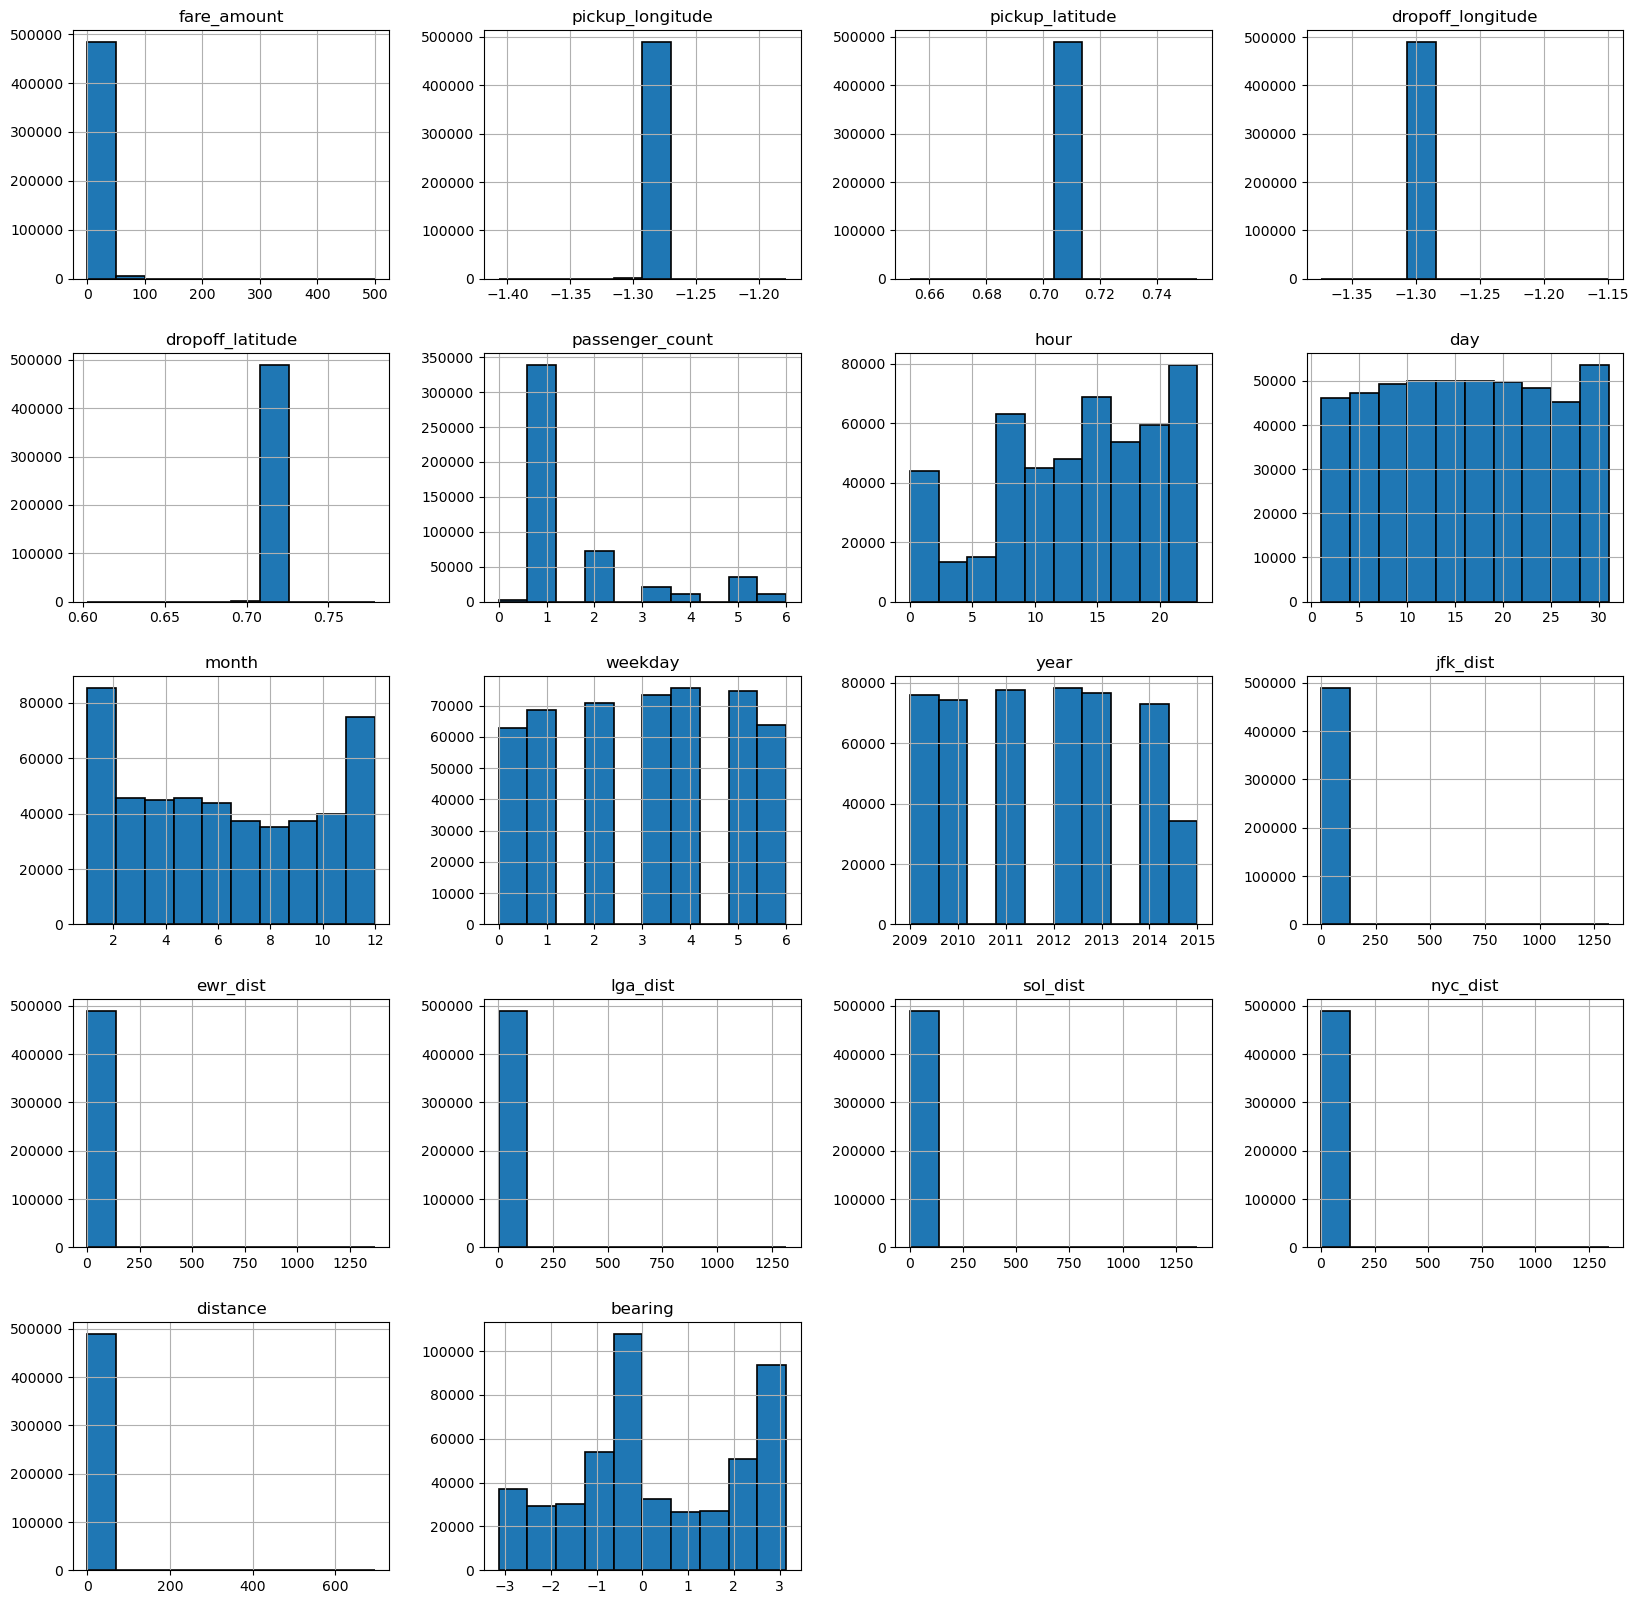

In [24]:
data.hist(edgecolor='black', linewidth=1.2)
fig=plt.gcf()
fig.set_size_inches(20,20)

# 3-Bivariate Analysis

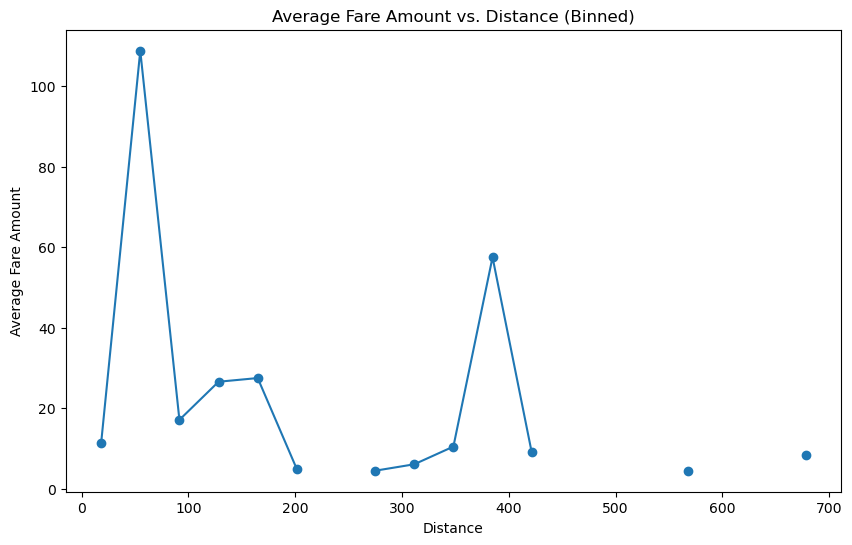

In [25]:
# 1. Binned Line Plot: Average Fare Amount vs. Distance
# Create bins for the 'distance' column
bins_distance = np.linspace(data['distance'].min(), data['distance'].max(), 20)
data['distance_bin'] = pd.cut(data['distance'], bins_distance)
# Calculate average fare_amount for each distance bin and compute bin centers
distance_agg = data.groupby('distance_bin')['fare_amount'].mean().reset_index()
distance_agg['bin_center'] = distance_agg['distance_bin'].apply(lambda x: x.mid)
plt.figure(figsize=(10, 6))
plt.plot(distance_agg['bin_center'], distance_agg['fare_amount'], marker='o', linestyle='-')
plt.title('Average Fare Amount vs. Distance (Binned)')
plt.xlabel('Distance')
plt.ylabel('Average Fare Amount')
plt.show()

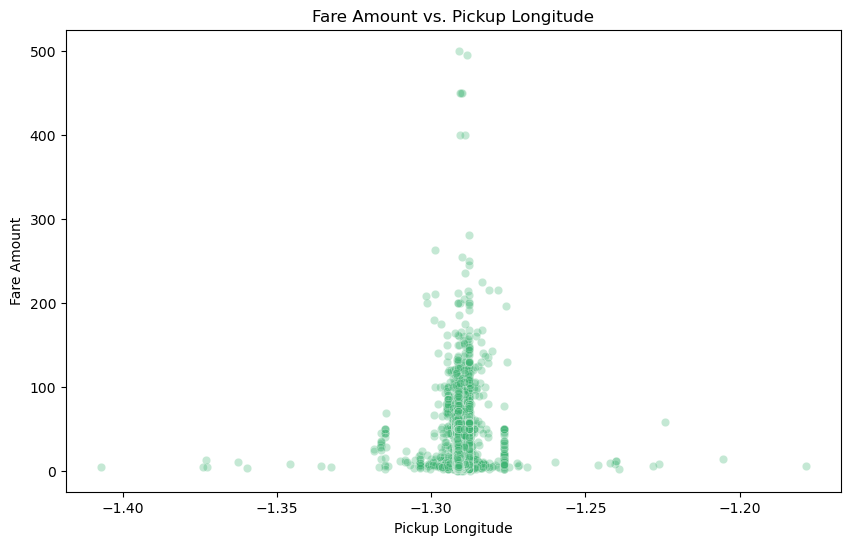

In [26]:
# 3. Scatter Plot: Fare Amount vs. Pickup Longitude
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pickup_longitude', y='fare_amount', data=data, alpha=0.3, color='mediumseagreen')
plt.title('Fare Amount vs. Pickup Longitude')
plt.xlabel('Pickup Longitude')
plt.ylabel('Fare Amount')
plt.show()

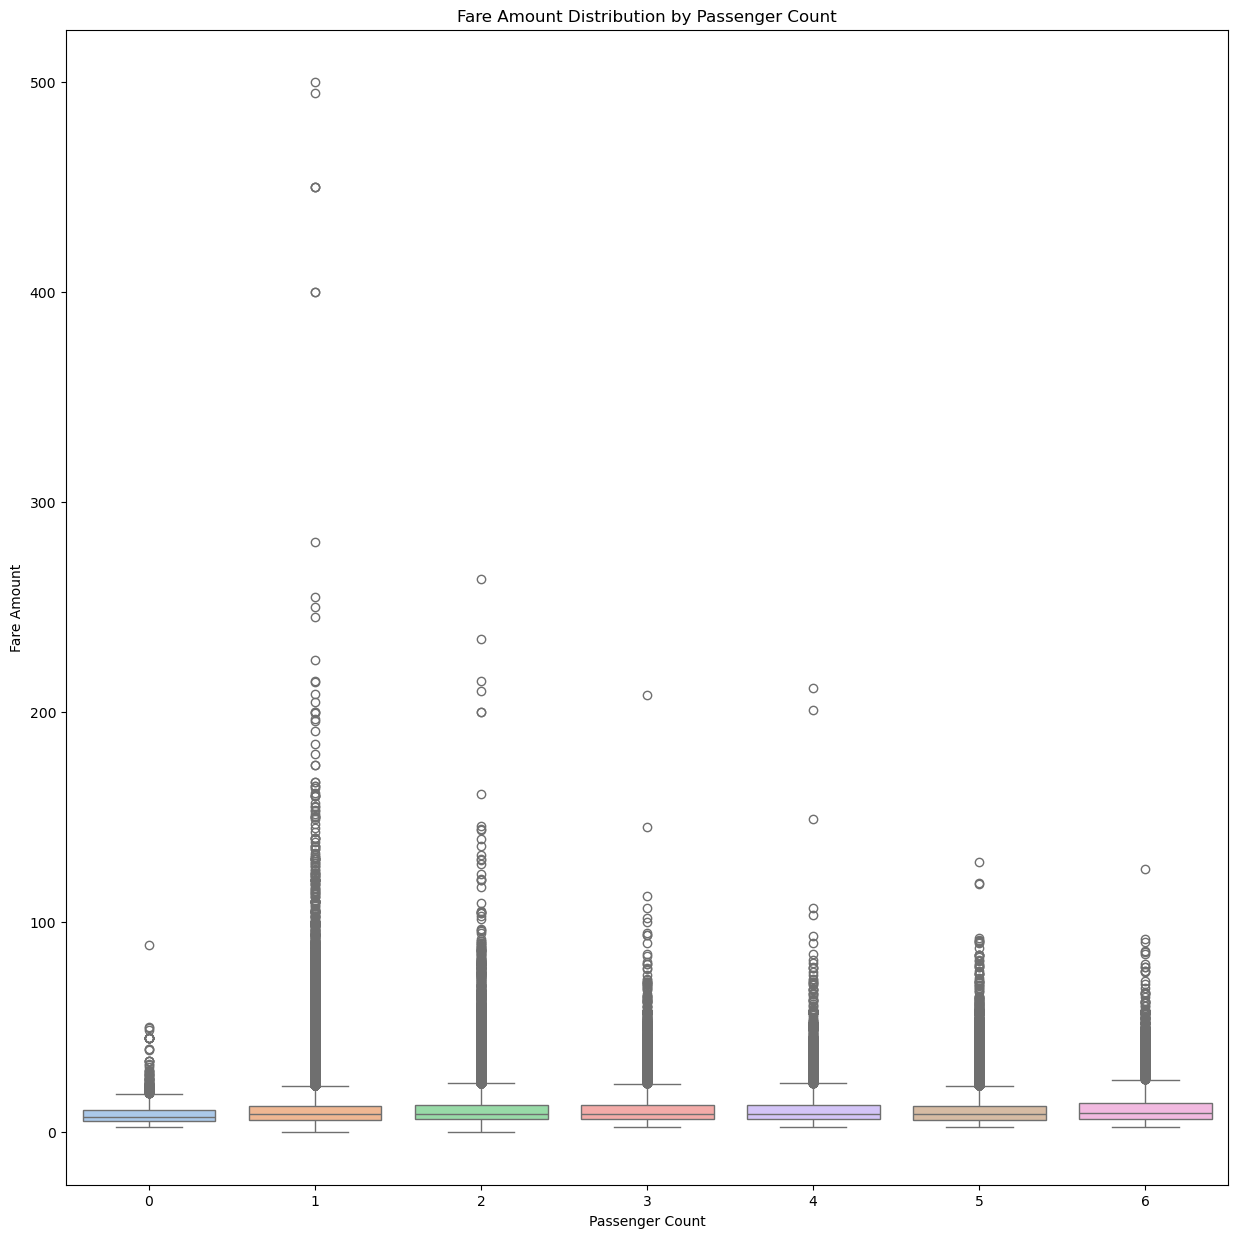

In [27]:
# 4. Box Plot: Fare Amount by Passenger Count
plt.figure(figsize=(15, 15))
sns.boxplot(x='passenger_count', y='fare_amount', data=data, palette='pastel')
plt.title('Fare Amount Distribution by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.show()

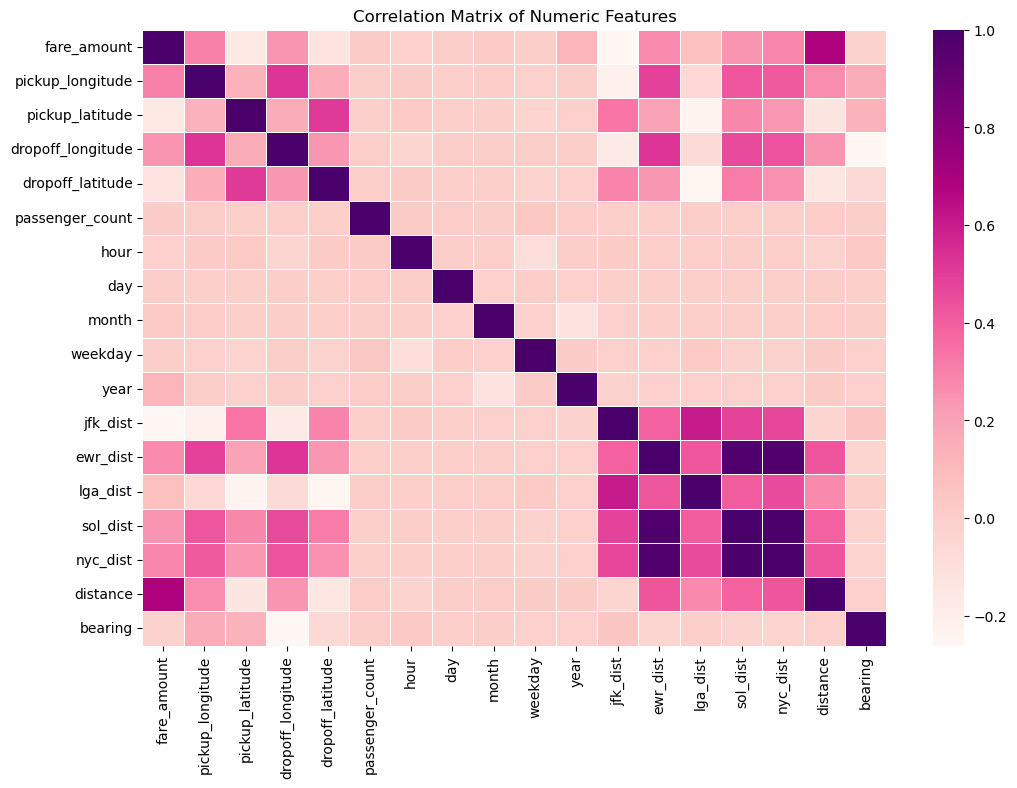

In [28]:
df_numeric = data.select_dtypes(include=[np.number])

# Compute correlation on numeric columns
corr_matrix = df_numeric.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='RdPu', linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489671 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   Car Condition      489671 non-null  object  
 1   Weather            489671 non-null  object  
 2   Traffic Condition  489671 non-null  object  
 3   fare_amount        489671 non-null  float64 
 4   pickup_longitude   489671 non-null  float64 
 5   pickup_latitude    489671 non-null  float64 
 6   dropoff_longitude  489671 non-null  float64 
 7   dropoff_latitude   489671 non-null  float64 
 8   passenger_count    489671 non-null  int64   
 9   hour               489671 non-null  int64   
 10  day                489671 non-null  int64   
 11  month              489671 non-null  int64   
 12  weekday            489671 non-null  int64   
 13  year               489671 non-null  int64   
 14  jfk_dist           489671 non-null  float64 
 15  ewr_dist           489671 non-null  flo

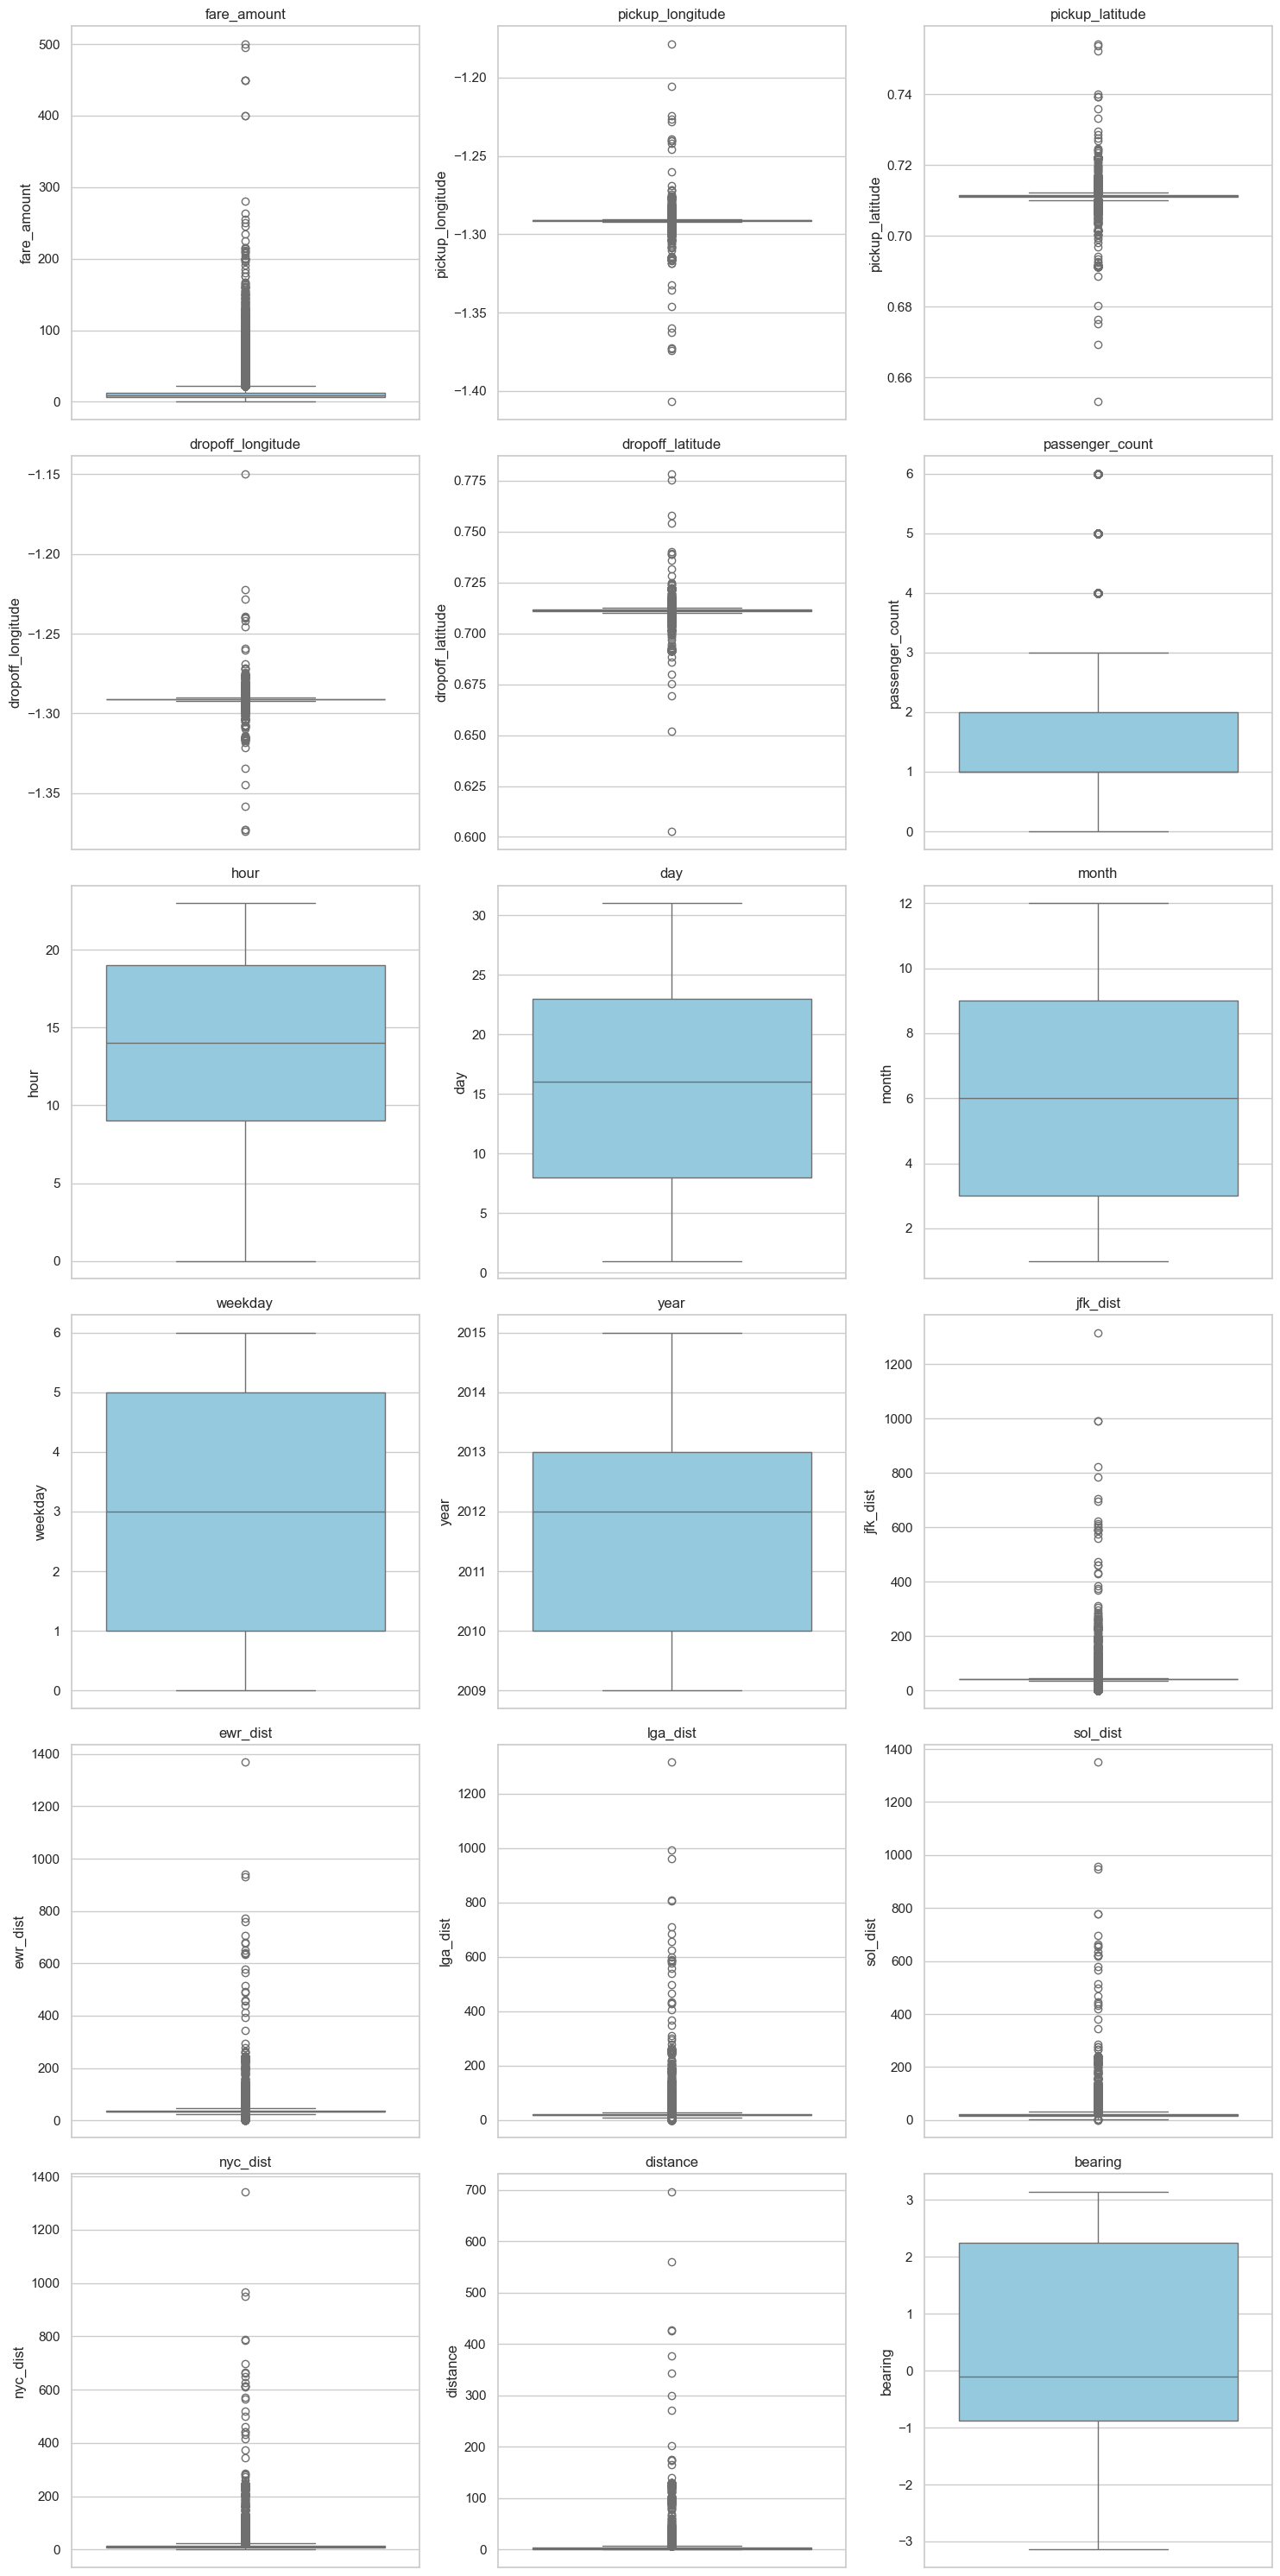

In [30]:
sns.set(style="whitegrid", palette="muted", color_codes=True)
numeric_columns = data.select_dtypes(include=[np.number]).columns
n_cols = 3  
n_rows = math.ceil(len(numeric_columns) / n_cols)
plt.figure(figsize=(5 * n_cols, 5 * n_rows))
for idx, col in enumerate(numeric_columns, 1):
    plt.subplot(n_rows, n_cols, idx)
    sns.boxplot(y=data[col], color='skyblue')
    plt.title(col)
    plt.xlabel('') 
plt.tight_layout()
plt.show()


 # 4-Multivariate Analysis📊# Sample a subset for speed (optional with large datasets)

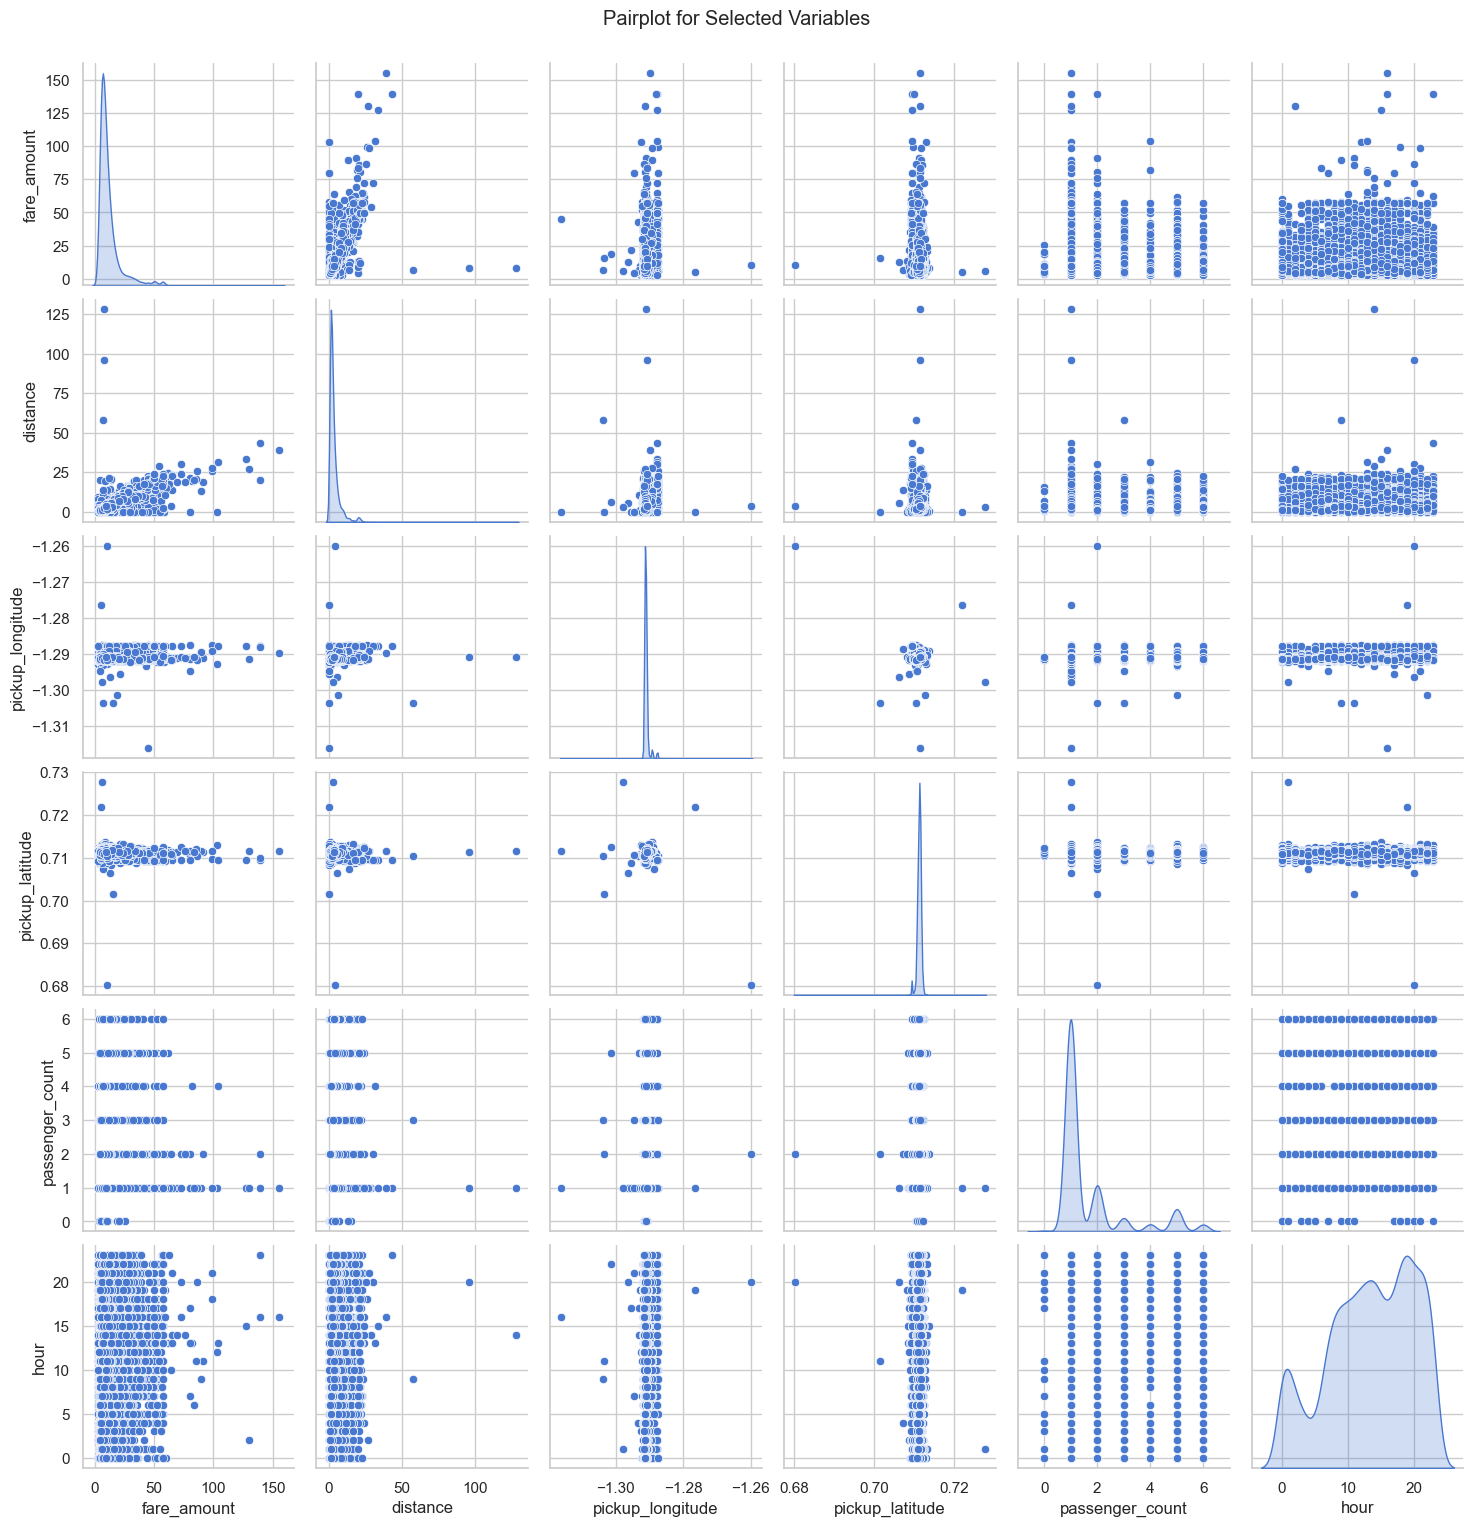

In [31]:
# Sample a subset for speed (optional with large datasets)
sample_data = data.sample(n=10000, random_state=42)
# Select a subset of columns to include in the pairplot
cols_to_include = ['fare_amount', 'distance', 'pickup_longitude', 'pickup_latitude', 'passenger_count', 'hour']

sns.pairplot(sample_data[cols_to_include], diag_kind='kde')
plt.suptitle("Pairplot for Selected Variables", y=1.02)
plt.show()

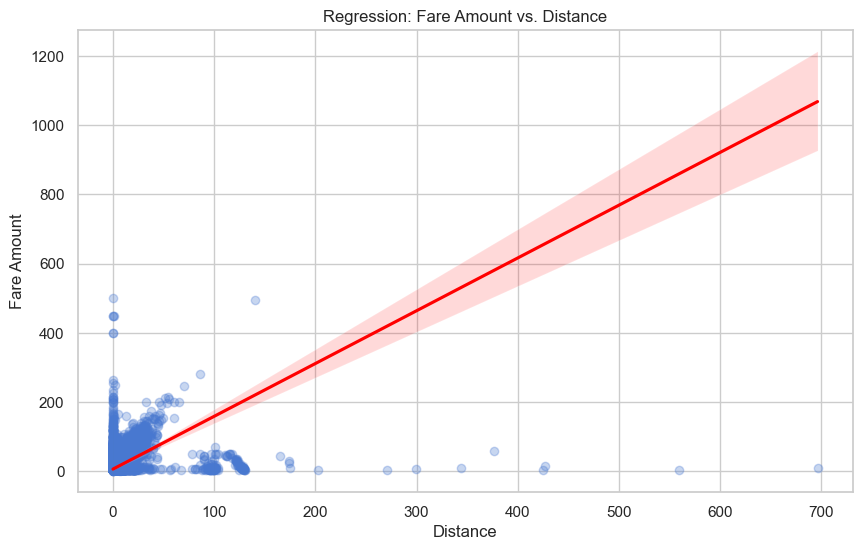

In [32]:
# 2. Regression Plot: Fare Amount vs. Distance
plt.figure(figsize=(10, 6))
sns.regplot(x='distance', y='fare_amount', data=data, scatter_kws={'alpha':0.3}, line_kws={"color": "red"})
plt.title('Regression: Fare Amount vs. Distance')
plt.xlabel('Distance')
plt.ylabel('Fare Amount')
plt.show()

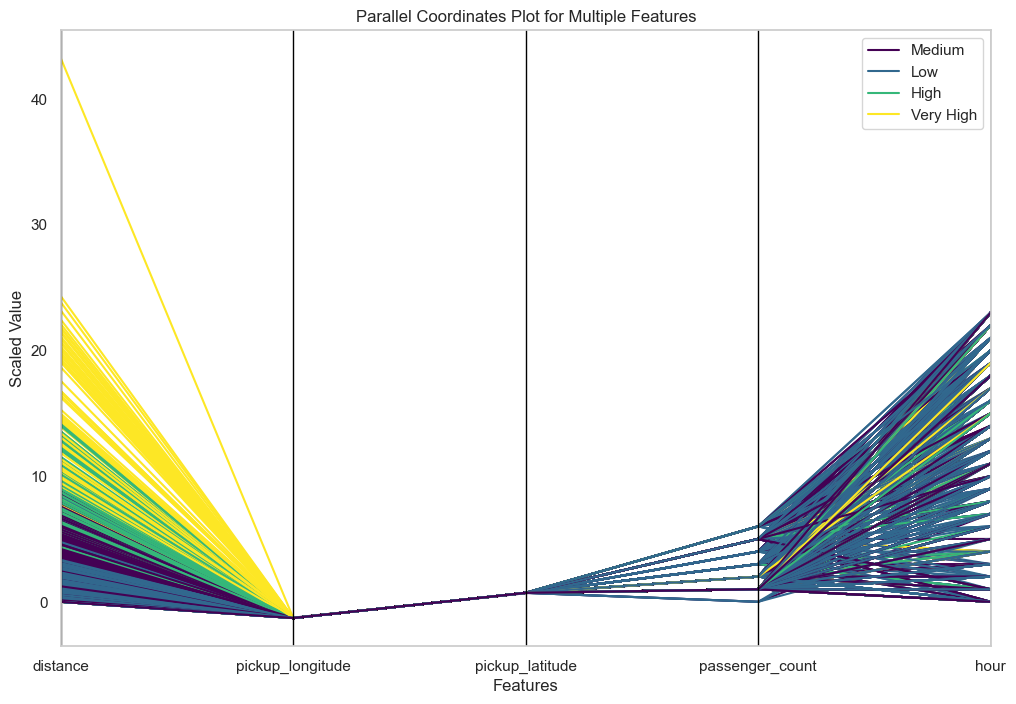

In [33]:
from pandas.plotting import parallel_coordinates
# Create a categorical fare bucket for coloring
fare_bins = [0, 10, 20, 30, data['fare_amount'].max()]
fare_labels = ['Low', 'Medium', 'High', 'Very High']
data['fare_category'] = pd.cut(data['fare_amount'], bins=fare_bins, labels=fare_labels)
# Select a subset of columns for the parallel coordinates plot
cols_parallel = ['fare_category', 'distance', 'pickup_longitude', 'pickup_latitude', 'passenger_count', 'hour']

plt.figure(figsize=(12, 8))
parallel_coordinates(data[cols_parallel].sample(n=2000, random_state=42), 'fare_category', colormap='viridis')
plt.title("Parallel Coordinates Plot for Multiple Features")
plt.xlabel("Features")
plt.ylabel("Scaled Value")
plt.show()


<a id='FeatureEngineering&DataTransformation'></a>

# 5-Feature Engineering & Data Transformation

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489671 entries, 0 to 499999
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   Car Condition      489671 non-null  object  
 1   Weather            489671 non-null  object  
 2   Traffic Condition  489671 non-null  object  
 3   fare_amount        489671 non-null  float64 
 4   pickup_longitude   489671 non-null  float64 
 5   pickup_latitude    489671 non-null  float64 
 6   dropoff_longitude  489671 non-null  float64 
 7   dropoff_latitude   489671 non-null  float64 
 8   passenger_count    489671 non-null  int64   
 9   hour               489671 non-null  int64   
 10  day                489671 non-null  int64   
 11  month              489671 non-null  int64   
 12  weekday            489671 non-null  int64   
 13  year               489671 non-null  int64   
 14  jfk_dist           489671 non-null  float64 
 15  ewr_dist           489671 non-null  flo

In [35]:
data['Weather_Rain'] = data['Weather'].apply(lambda x: 1 if x == 'rainy' else 0)
data['Weather_Stormy'] = data['Weather'].apply(lambda x: 1 if x == 'stormy' else 0)
data['Traffic Condition_Heavy'] = data['Traffic Condition'].apply(lambda x: 1 if x == 'Congested Traffic' else 0)

In [36]:
data['rain_heavy_traffic'] = data['Weather_Rain'] * data['Traffic Condition_Heavy']
data['storm_heavy_traffic'] = data['Weather_Stormy'] * data['Traffic Condition_Heavy']

In [37]:
label_encoder = LabelEncoder()
data['Traffic Condition'] = label_encoder.fit_transform(data['Traffic Condition'])

In [38]:
data['Car Condition'] = label_encoder.fit_transform(data['Car Condition'])

In [39]:
data['Weather'] = label_encoder.fit_transform(data['Weather'])

In [40]:
weather_map = {
    0: "cloudy",
    1: "rainy",
    2: "stormy",
    3: "sunny",
    4: "windy"
}
data = data.copy()
data ["Weather_str"] = data ["Weather"].map(weather_map)
weather_encoder = LabelEncoder()
data ["Weather_encoded"] = weather_encoder.fit_transform(data ["Weather_str"])

                    Feature  Importance
18                 distance    0.736077
5         dropoff_longitude    0.031896
15                 lga_dist    0.030044
13                 jfk_dist    0.027672
12                     year    0.024308
19                  bearing    0.018579
17                 nyc_dist    0.018263
6          dropoff_latitude    0.017053
14                 ewr_dist    0.014140
3          pickup_longitude    0.011875
16                 sol_dist    0.011316
8                      hour    0.010915
4           pickup_latitude    0.010600
9                       day    0.008555
10                    month    0.007726
11                  weekday    0.006184
0             Car Condition    0.002925
1                   Weather    0.002831
7           passenger_count    0.002718
25          Weather_encoded    0.002214
2         Traffic Condition    0.002079
20             Weather_Rain    0.001017
21           Weather_Stormy    0.001013
22  Traffic Condition_Heavy    0.000000


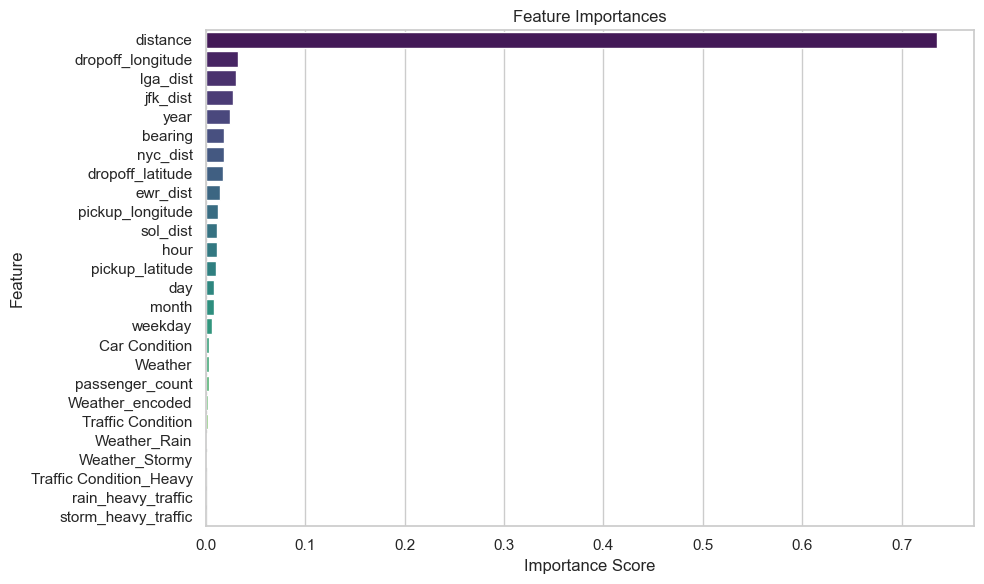

In [41]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def determine_feature_importance(data, target='fare_amount', n_estimators=100, random_state=42):
    xx = data.drop(columns=[target])
    xx_numeric = xx.select_dtypes(include=[np.number])
    yy = data[target]
    
    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state)
    rf.fit(xx_numeric, yy)
    
    # Extract feature importances
    importances = rf.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': xx_numeric.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    return importance_df

def plot_feature_importance(importance_df, title="Feature Importances"):
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
    plt.title(title)
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

importance_df = determine_feature_importance(data, target='fare_amount')
print(importance_df)
plot_feature_importance(importance_df)


In [42]:
data.columns

Index(['Car Condition', 'Weather', 'Traffic Condition', 'fare_amount',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month',
       'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist',
       'nyc_dist', 'distance', 'bearing', 'distance_bin', 'fare_category',
       'Weather_Rain', 'Weather_Stormy', 'Traffic Condition_Heavy',
       'rain_heavy_traffic', 'storm_heavy_traffic', 'Weather_str',
       'Weather_encoded'],
      dtype='object')

In [43]:
data.drop(columns=['storm_heavy_traffic','rain_heavy_traffic','Traffic Condition_Heavy','Weather_Stormy','Weather_Rain'], inplace=True)

In [44]:
data.drop(columns=['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist','fare_category','distance_bin'], inplace=True)

In [45]:
data.drop(columns=['Weather_str','Weather','weekday'], inplace=True)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489671 entries, 0 to 499999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Car Condition      489671 non-null  int32  
 1   Traffic Condition  489671 non-null  int32  
 2   fare_amount        489671 non-null  float64
 3   pickup_longitude   489671 non-null  float64
 4   pickup_latitude    489671 non-null  float64
 5   dropoff_longitude  489671 non-null  float64
 6   dropoff_latitude   489671 non-null  float64
 7   passenger_count    489671 non-null  int64  
 8   hour               489671 non-null  int64  
 9   day                489671 non-null  int64  
 10  month              489671 non-null  int64  
 11  year               489671 non-null  int64  
 12  distance           489671 non-null  float64
 13  bearing            489671 non-null  float64
 14  Weather_encoded    489671 non-null  int32  
dtypes: float64(7), int32(3), int64(5)
memory usage: 54.2 MB


<a id='SplittingData'></a>

# 6-Splitting Data

In [48]:
X= data.drop(['fare_amount'], axis=1)
y = data['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
# Do scaling brfore Model training 
from sklearn.preprocessing import MinMaxScaler
X_scaler = MinMaxScaler()
X_scaler.fit(X_train)
X_train = pd.DataFrame(X_scaler.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(X_scaler.transform(X_test), columns=X_test.columns)
y_scaler = MinMaxScaler()
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)
y_scaler.fit(y_train)
y_train = y_scaler.transform(y_train)
y_test = y_scaler.transform(y_test)

<a id='ModelSelection'></a>

# 7- Model Selection

In [50]:
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    #'DecisionTree': DecisionTreeRegressor(random_state=42),
    #'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    #'XGBoost': XGBRegressor(n_estimators=100, random_state=42)  
}

<a id='ModelTraining'></a>

# 8-Model Training⚙️

In [51]:
results = {}
model_objects = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} -> MSE: {mse:.8f}, RMSE: {rmse:.8f}, MAE: {mae:.8f}, R²: {r2:.8f}")
    results[name] = mse
    model_objects[name] = model

Linear -> MSE: 0.00017499, RMSE: 0.01322829, MAE: 0.00630323, R²: 0.55114829
Ridge -> MSE: 0.00017785, RMSE: 0.01333593, MAE: 0.00653820, R²: 0.54381349
Lasso -> MSE: 0.00038987, RMSE: 0.01974506, MAE: 0.01209521, R²: -0.00002899
GradientBoosting -> MSE: 0.00007661, RMSE: 0.00875298, MAE: 0.00389465, R²: 0.80347971


In [52]:
results[name] = mse
model_objects[name] = model
best_model_name = min(results, key=results.get)
best_model_mse = results[best_model_name]
best_model = model_objects[best_model_name]
print(f"\nBest Model: {best_model_name} with MSE: {best_model_mse:.8f}")


Best Model: GradientBoosting with MSE: 0.00007661


<a id='HyperparameterTuning'></a>

# 9-Hyperparameter Tuning🛠️

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 150,200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}
gbr = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid,
                           cv=5,  
                           scoring='neg_mean_squared_log_error', 
                           n_jobs=-1,  
                           verbose=1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", best_params)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


<a id='ModelEvaluation'></a>

# 10-Model Evaluation📝

In [ ]:
# Evaluate the best model on the test data
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Evaluation Metrics:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

<a id='FinalModelandDeploymentwithDjango'></a>

# 11-Final Model and Deployment with Django🔖

In [ ]:
import joblib
# Save everything needed for inference
joblib.dump(best_model,'Uber_model.pkl')
joblib.dump(X_scaler, 'X_scaler.pkl')
joblib.dump(y_scaler, 'y_scaler.pkl')

### END OF this Notebook, Made by Menna Khaled💗 